In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# Set style
sns.set_theme(style="whitegrid")

# Define paths
base_path = r'c:\Files\Degree\FYP\FYP_ver5\Results\10seeds_cv5_runs\2_Test_Add_LayerNorm'
datasets = ['Reddit', 'Twitter']

# Function to find 10S model folders
def find_model_folders(base_path, datasets):
    model_folders = []
    for dataset in datasets:
        dataset_path = os.path.join(base_path, dataset)
        if not os.path.exists(dataset_path):
            continue
            
        for folder in os.listdir(dataset_path):
            if folder.startswith('10S') and os.path.isdir(os.path.join(dataset_path, folder)):
                # Check if history file exists
                history_file = os.path.join(dataset_path, folder, f"{folder}_training_history.xlsx")
                if os.path.exists(history_file):
                    model_folders.append({
                        'dataset': dataset,
                        'folder': folder,
                        'path': history_file,
                        'is_baseline': 'baseline' in folder.lower()
                    })
    return model_folders

models = find_model_folders(base_path, datasets)
print(f"Found {len(models)} models:")
for m in models:
    print(f"  - {m['dataset']}: {m['folder']}")

Found 8 models:
  - Reddit: 10SR_tcn_model_fine_tune_mb_pool_ln
  - Reddit: 10SR_tcn_model_fine_tune_mb_seqOut_sgd_ln
  - Reddit: 10SR_tcn_model_mb_precompute_pool_adam_ln
  - Reddit: 10SR_tcn_model_mb_precompute_pool_SGD_ln
  - Twitter: 10ST_tcn_model_fine_tune_mb_pool_ln
  - Twitter: 10ST_tcn_model_fine_tune_mb_seqOut_sgd_ln
  - Twitter: 10ST_tcn_model_mb_precompute_pool_adam_ln
  - Twitter: 10ST_tcn_model_mb_precompute_pool_SGD_ln


In [3]:
def process_model_history(model_info):
    file_path = model_info['path']
    is_baseline = model_info['is_baseline']
    
    try:
        sheets = pd.read_excel(file_path, sheet_name=None)
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return None

    all_folds_data = []

    for sheet_name, df in sheets.items():
        # Normalize column names to lowercase for easier checking
        df.columns = [c.lower() for c in df.columns]
        
        # Map expected columns
        col_map = {
            'train_loss': 'loss',
            'val_loss': 'val_loss',
            'train_accuracy': 'accuracy',
            'val_accuracy': 'val_accuracy'
        }
        
        # Rename columns if they match our expected keys
        df = df.rename(columns=col_map)
        
        # Ensure required columns exist
        if 'loss' not in df.columns or 'val_loss' not in df.columns:
            # Try checking if 'loss' is just 'loss' (keras default)
            if 'loss' not in df.columns:
                 # print(f"Missing loss columns in {sheet_name}. Columns: {df.columns}")
                 continue
        
        # Reset index to ensure it's 0-based integers
        df = df.reset_index(drop=True)
            
        # Handle Early Stopping
        if not is_baseline:
            # Find the epoch with the minimum validation loss
            # We assume the model was restored to this state.
            # Any epochs after this were part of the 'patience' and should be discarded
            # as per the user's request to "not plot for the other curves".
            best_epoch_idx = df['val_loss'].idxmin()
            
            # Truncate the dataframe to keep history up to the best epoch
            # (Since we restore best weights, the subsequent epochs are discarded)
            df_subset = df.iloc[:best_epoch_idx + 1].copy()
        else:
            # Baseline: Keep all epochs
            df_subset = df.copy()
            
        # Add Epoch column (1-based) if not present, or ensure it's correct
        if 'epoch' not in df_subset.columns:
            df_subset['Epoch'] = range(1, len(df_subset) + 1)
        else:
            # Capitalize Epoch for consistency
            df_subset = df_subset.rename(columns={'epoch': 'Epoch'})
            
        df_subset['Fold_Sheet'] = sheet_name
        
        all_folds_data.append(df_subset)
        
    if not all_folds_data:
        return None
        
    return pd.concat(all_folds_data, ignore_index=True)

Processing 10SR_tcn_model_fine_tune_mb_pool_ln...
  - Found 50 runs/folds.
Saved to c:\Files\Degree\FYP\FYP_ver5\Results\10seeds_cv5_runs\2_Test_Add_LayerNorm\Reddit\10SR_tcn_model_fine_tune_mb_pool_ln\10SR_tcn_model_fine_tune_mb_pool_ln_learning_curves_detailed.png


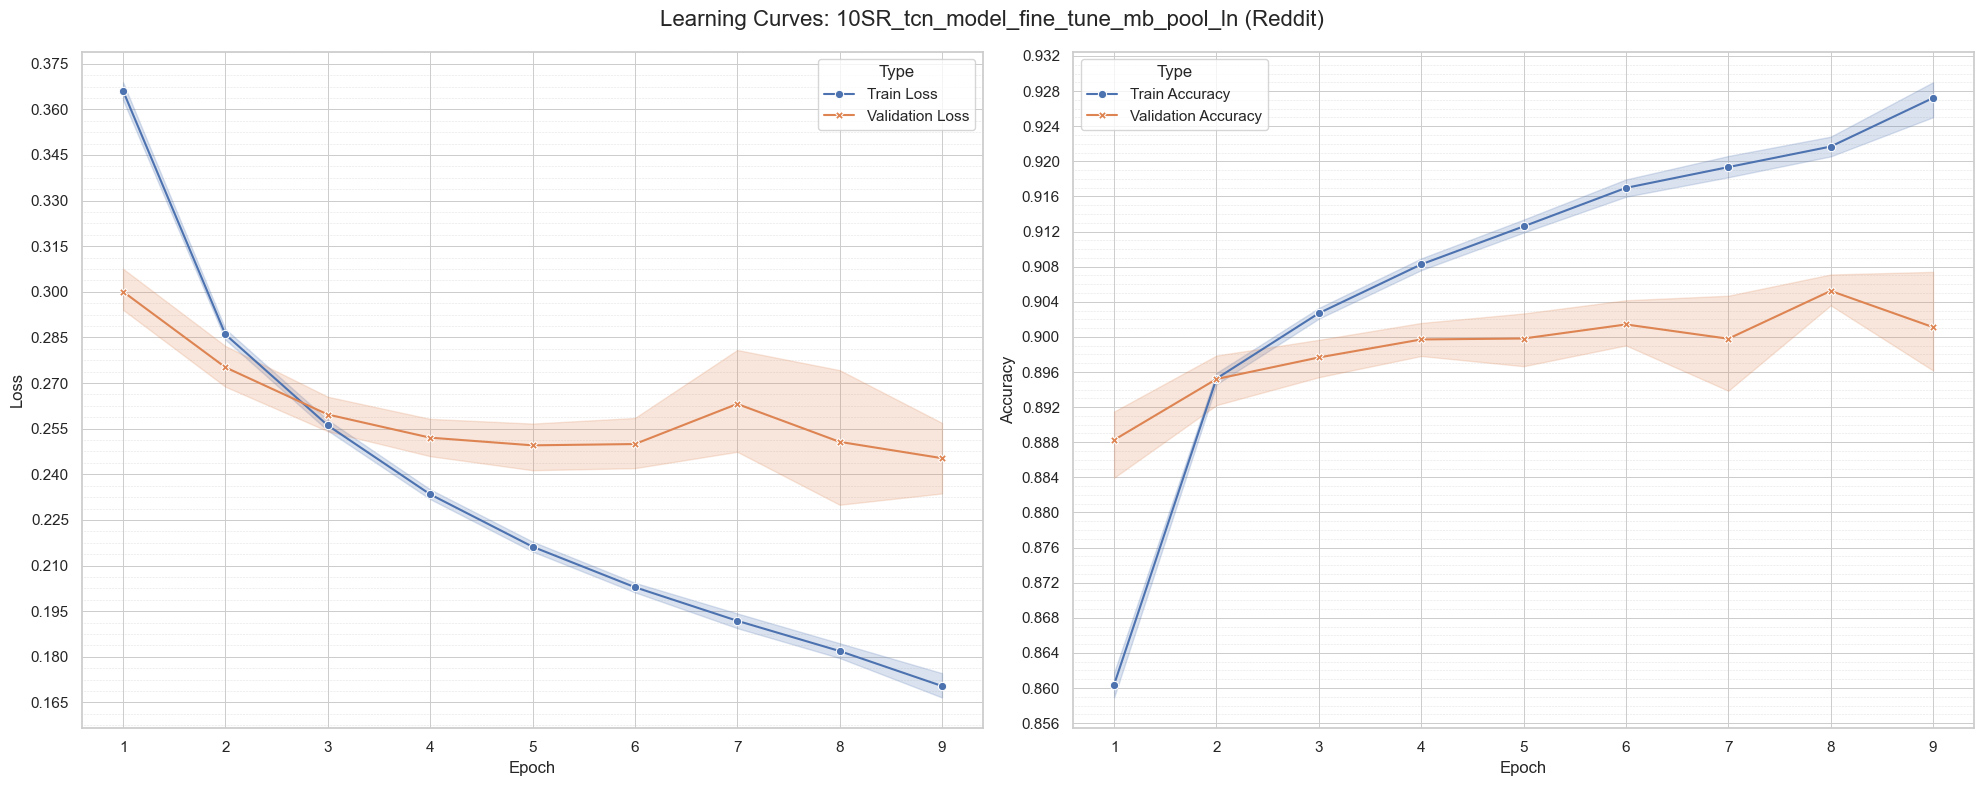

Processing 10SR_tcn_model_fine_tune_mb_seqOut_sgd_ln...
  - Found 25 runs/folds.
Saved to c:\Files\Degree\FYP\FYP_ver5\Results\10seeds_cv5_runs\2_Test_Add_LayerNorm\Reddit\10SR_tcn_model_fine_tune_mb_seqOut_sgd_ln\10SR_tcn_model_fine_tune_mb_seqOut_sgd_ln_learning_curves_detailed.png


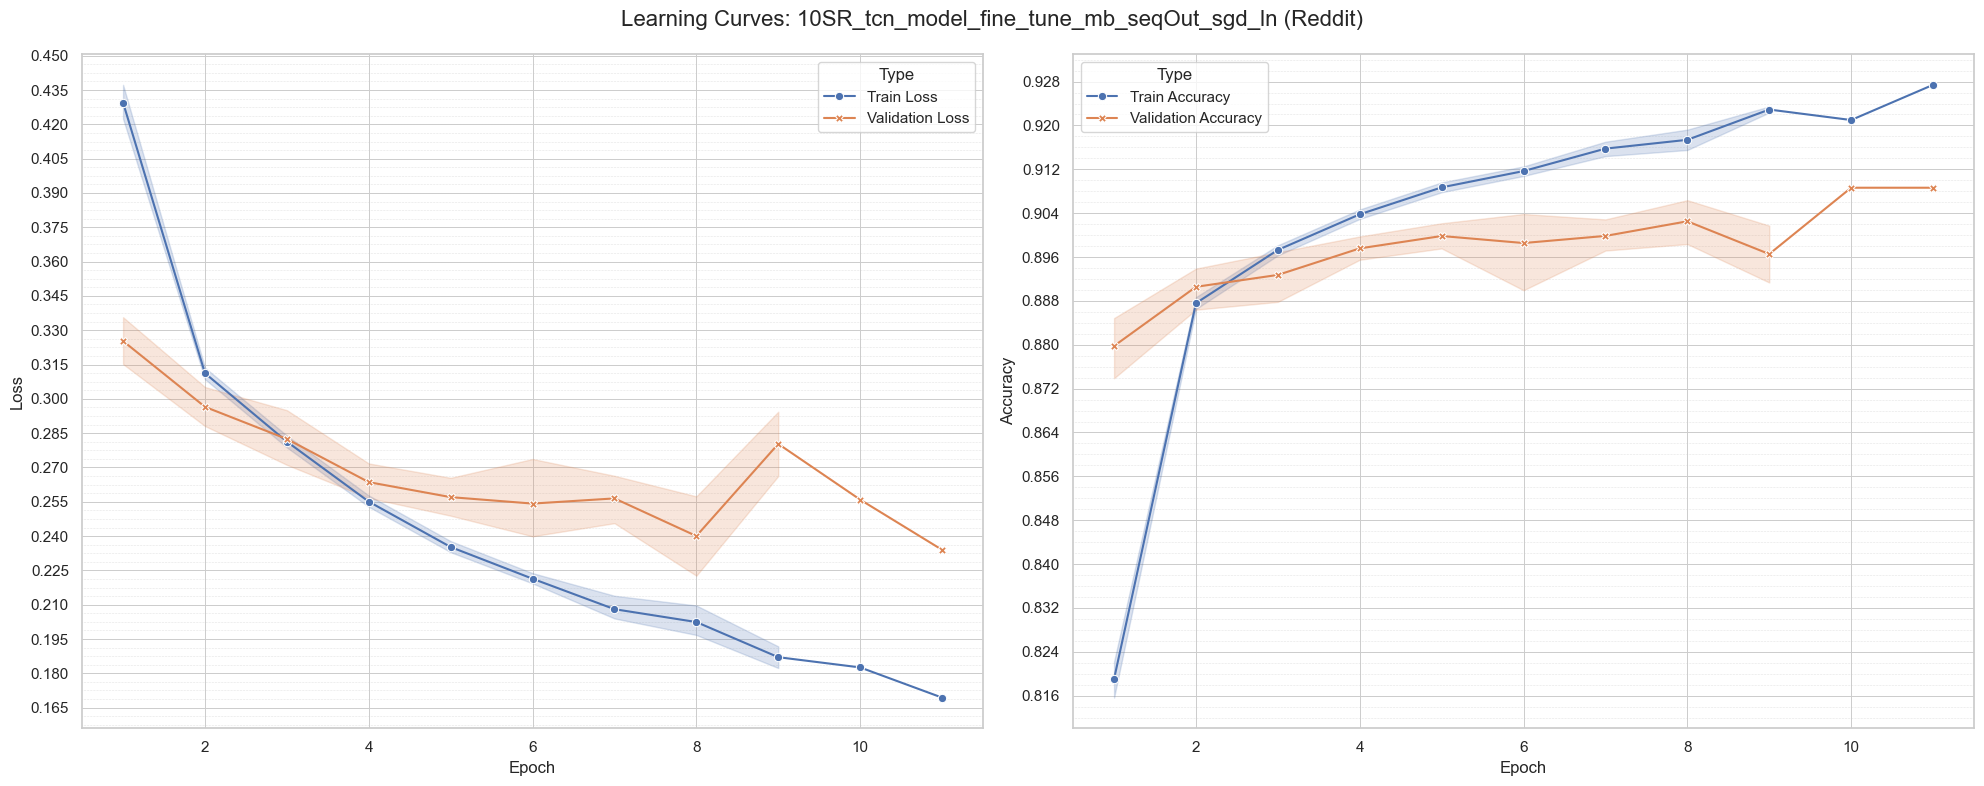

Processing 10SR_tcn_model_mb_precompute_pool_adam_ln...
  - Found 50 runs/folds.
Saved to c:\Files\Degree\FYP\FYP_ver5\Results\10seeds_cv5_runs\2_Test_Add_LayerNorm\Reddit\10SR_tcn_model_mb_precompute_pool_adam_ln\10SR_tcn_model_mb_precompute_pool_adam_ln_learning_curves_detailed.png


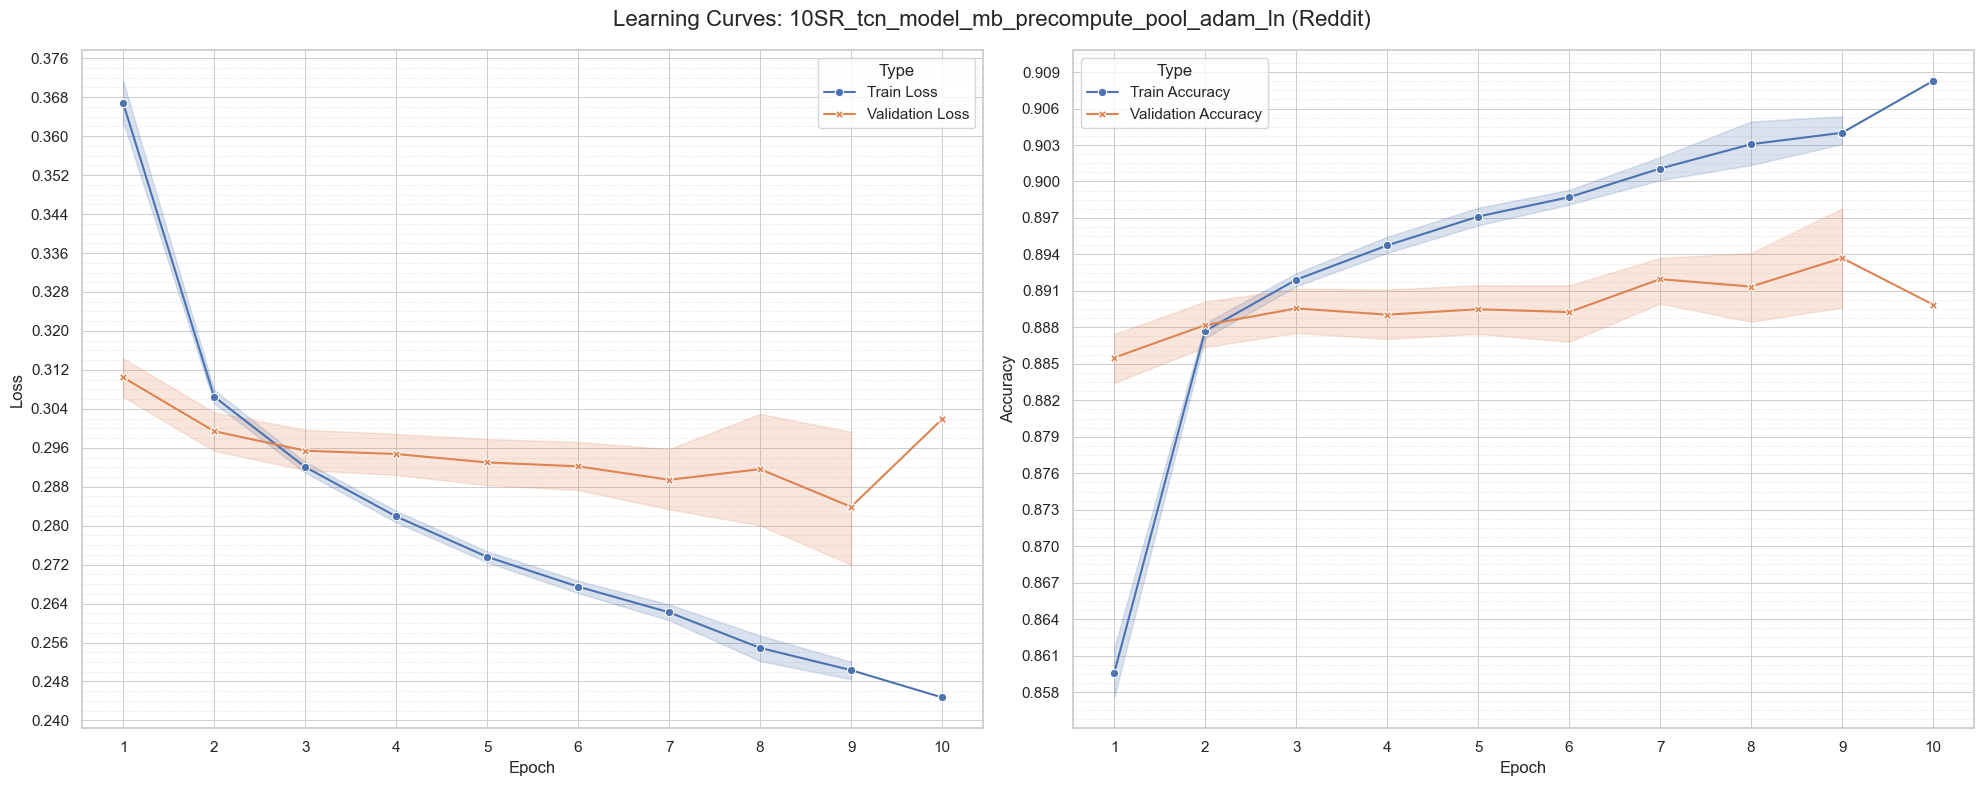

Processing 10SR_tcn_model_mb_precompute_pool_SGD_ln...
  - Found 50 runs/folds.
Saved to c:\Files\Degree\FYP\FYP_ver5\Results\10seeds_cv5_runs\2_Test_Add_LayerNorm\Reddit\10SR_tcn_model_mb_precompute_pool_SGD_ln\10SR_tcn_model_mb_precompute_pool_SGD_ln_learning_curves_detailed.png


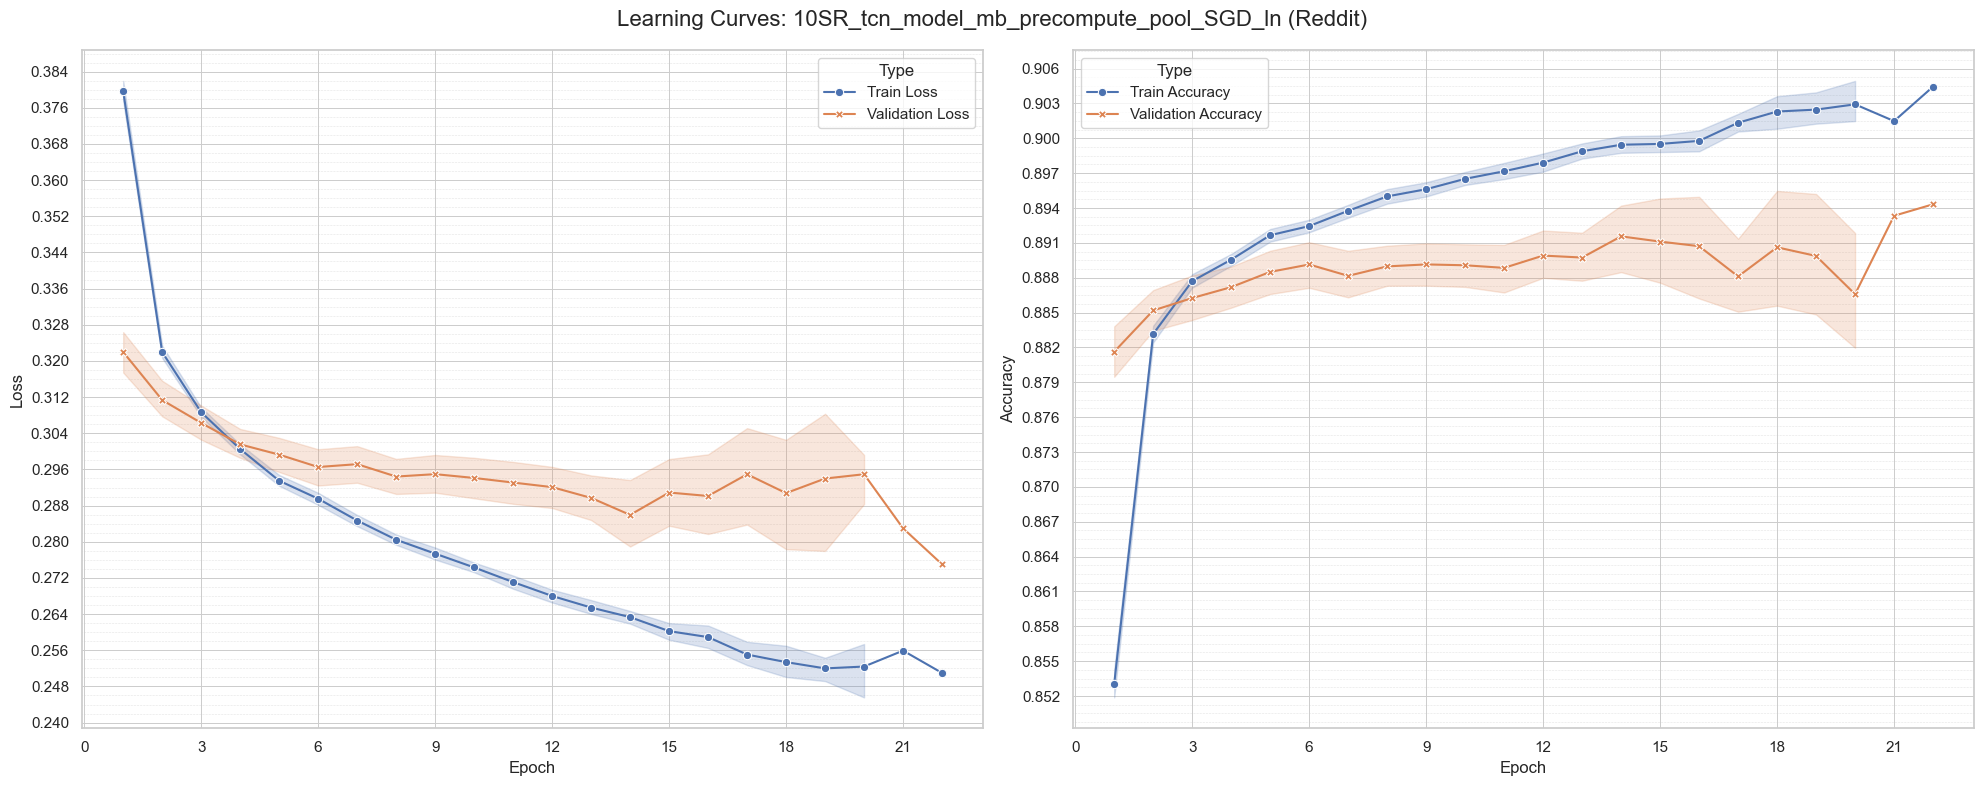

Processing 10ST_tcn_model_fine_tune_mb_pool_ln...
  - Found 50 runs/folds.
Saved to c:\Files\Degree\FYP\FYP_ver5\Results\10seeds_cv5_runs\2_Test_Add_LayerNorm\Twitter\10ST_tcn_model_fine_tune_mb_pool_ln\10ST_tcn_model_fine_tune_mb_pool_ln_learning_curves_detailed.png


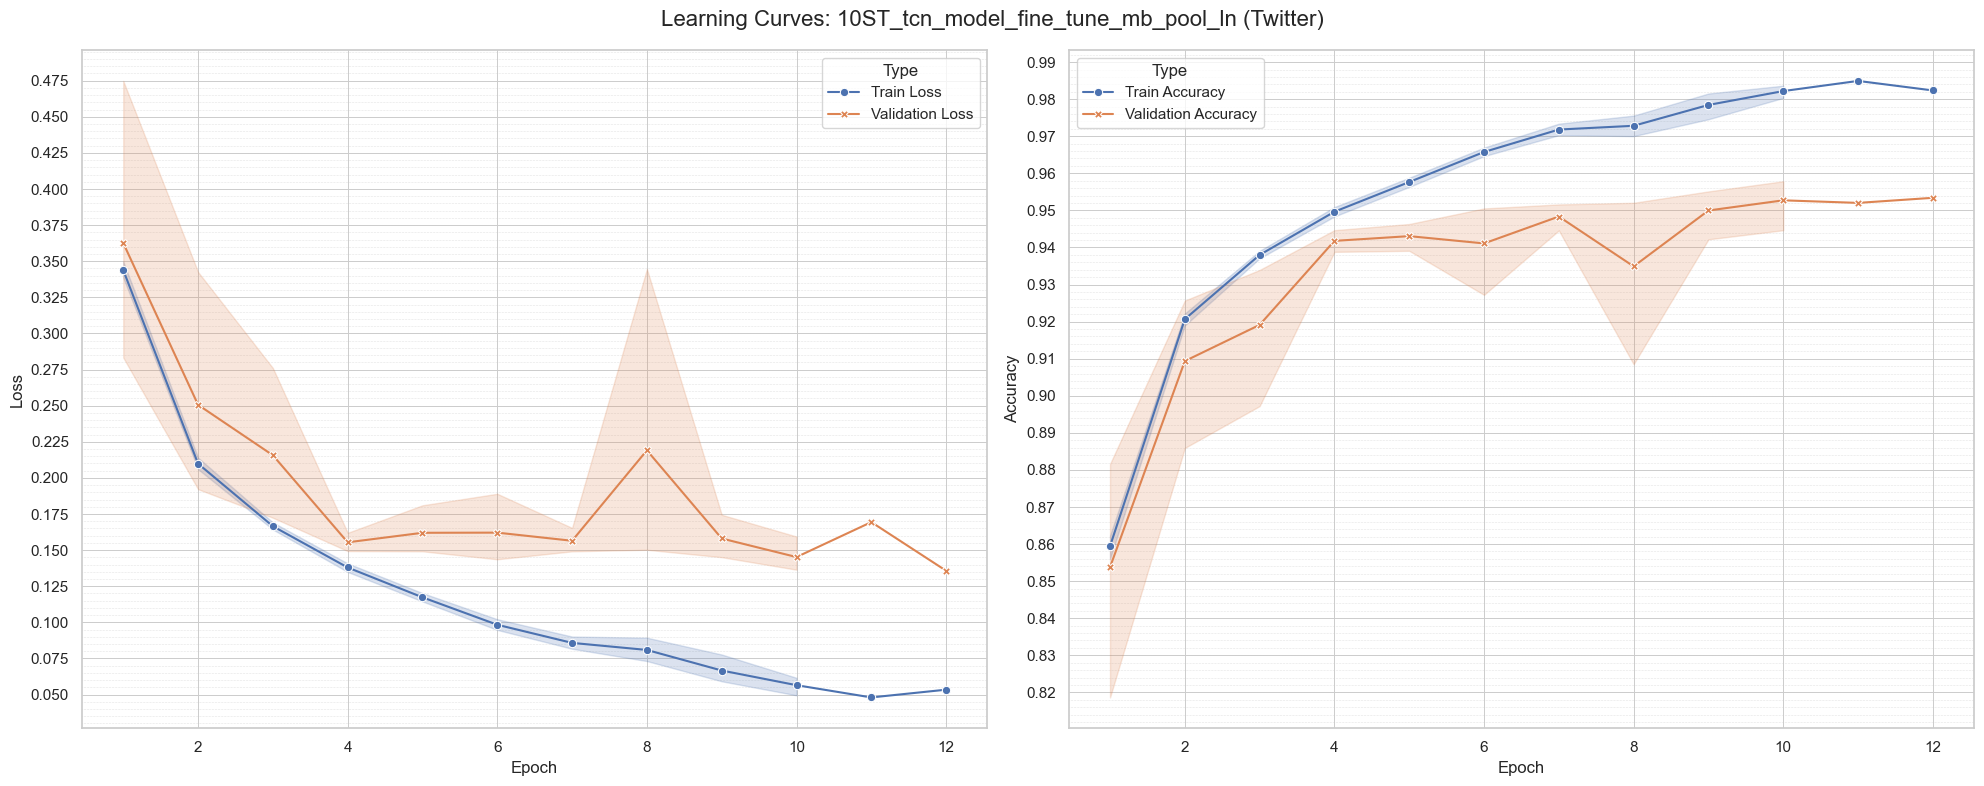

Processing 10ST_tcn_model_fine_tune_mb_seqOut_sgd_ln...
  - Found 50 runs/folds.
Saved to c:\Files\Degree\FYP\FYP_ver5\Results\10seeds_cv5_runs\2_Test_Add_LayerNorm\Twitter\10ST_tcn_model_fine_tune_mb_seqOut_sgd_ln\10ST_tcn_model_fine_tune_mb_seqOut_sgd_ln_learning_curves_detailed.png


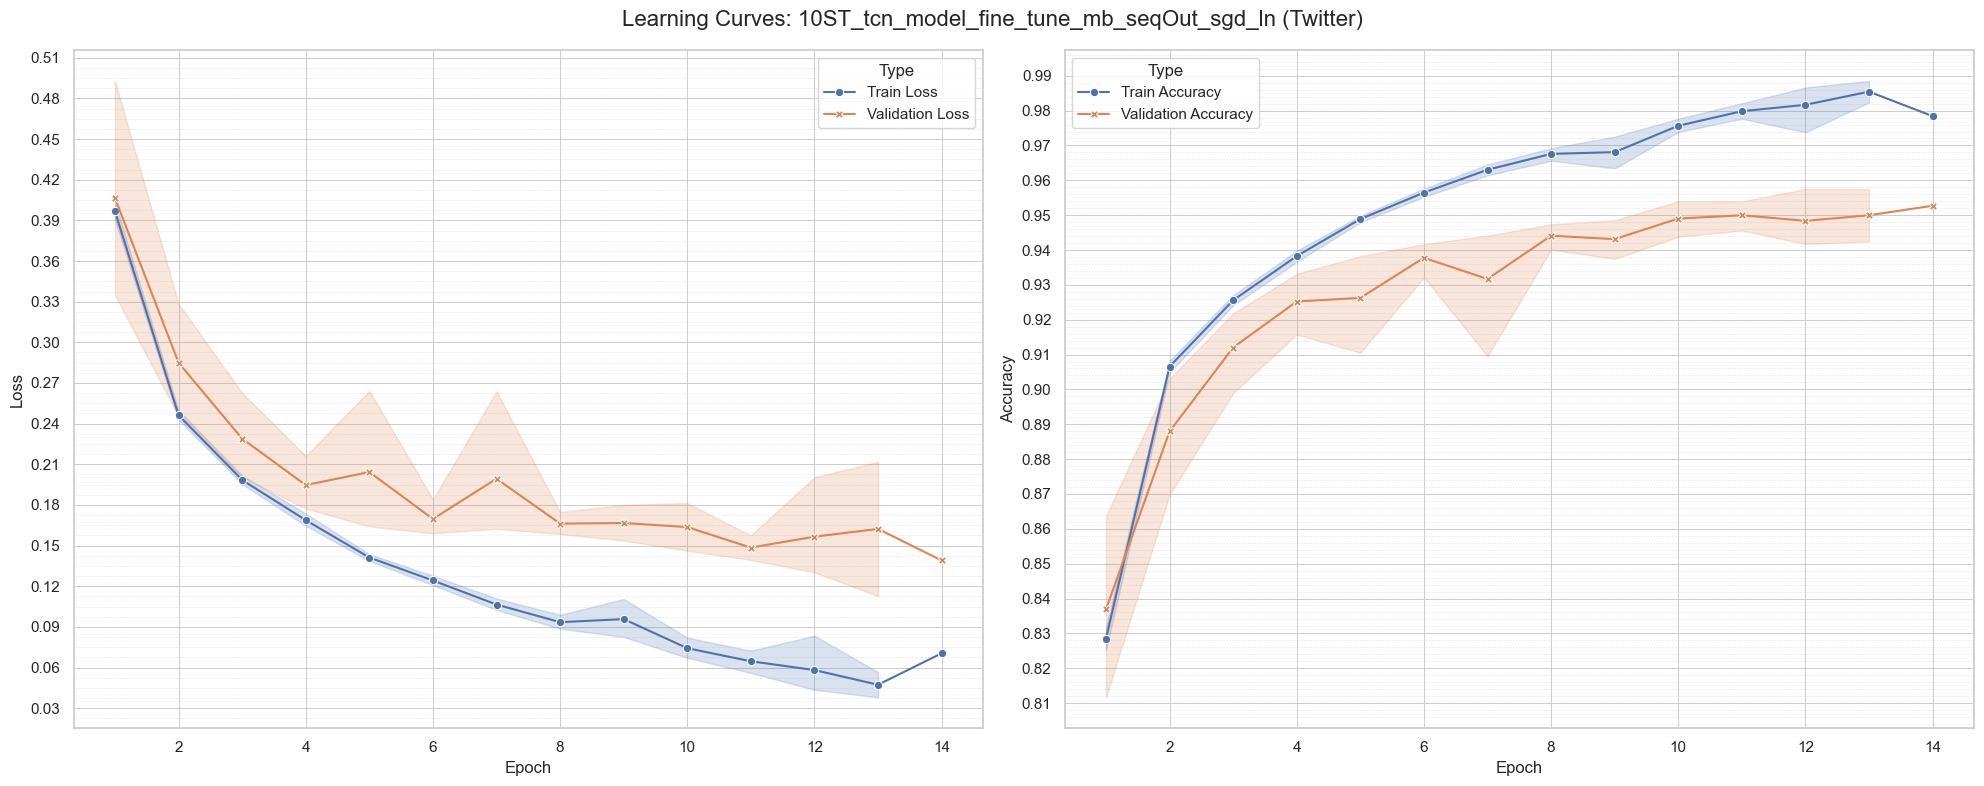

Processing 10ST_tcn_model_mb_precompute_pool_adam_ln...
  - Found 50 runs/folds.
Saved to c:\Files\Degree\FYP\FYP_ver5\Results\10seeds_cv5_runs\2_Test_Add_LayerNorm\Twitter\10ST_tcn_model_mb_precompute_pool_adam_ln\10ST_tcn_model_mb_precompute_pool_adam_ln_learning_curves_detailed.png


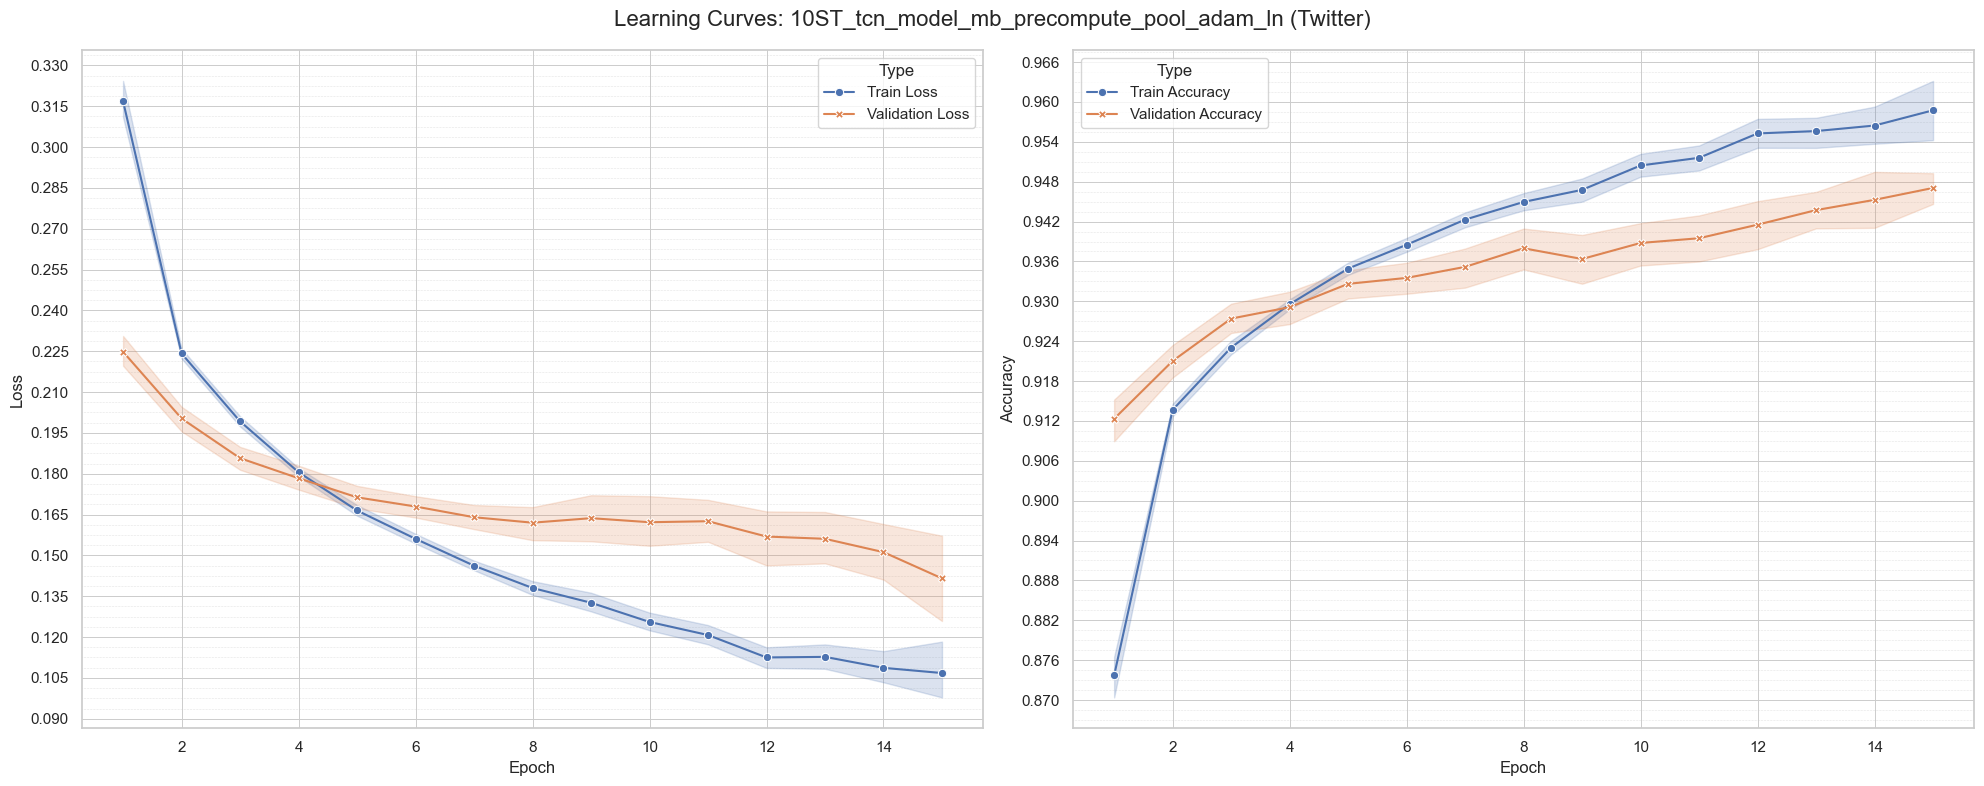

Processing 10ST_tcn_model_mb_precompute_pool_SGD_ln...
  - Found 50 runs/folds.
Saved to c:\Files\Degree\FYP\FYP_ver5\Results\10seeds_cv5_runs\2_Test_Add_LayerNorm\Twitter\10ST_tcn_model_mb_precompute_pool_SGD_ln\10ST_tcn_model_mb_precompute_pool_SGD_ln_learning_curves_detailed.png


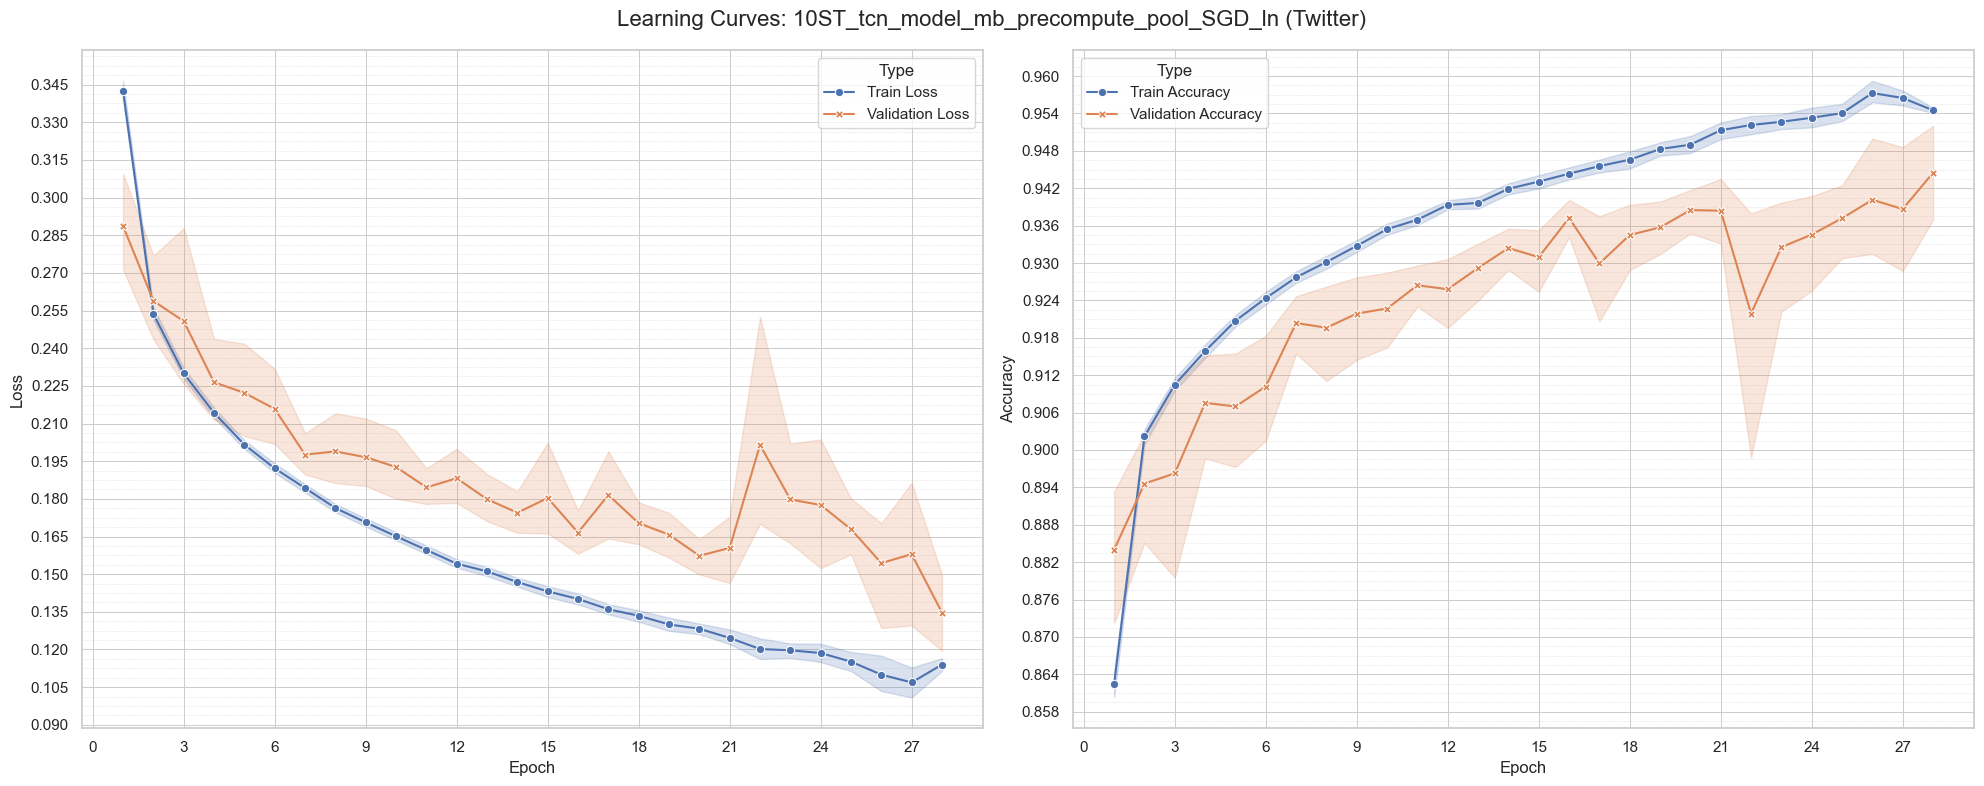

All plots generated.


In [4]:
import matplotlib.ticker as ticker

# Plotting Loop
for model in models:
    print(f"Processing {model['folder']}...")
    df_history = process_model_history(model)
    
    if df_history is None:
        print(f"Skipping {model['folder']} (No data)")
        continue
        
    # Count number of unique runs (folds/sheets)
    num_folds = df_history['Fold_Sheet'].nunique()
    print(f"  - Found {num_folds} runs/folds.")
    
    has_accuracy = 'accuracy' in df_history.columns and 'val_accuracy' in df_history.columns

    # Create figure
    if has_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))
        ax_loss = axes[0]
        ax_acc = axes[1]
    else:
        fig, ax_loss = plt.subplots(1, 1, figsize=(10, 8))
        axes = [ax_loss] # For consistency if needed
        ax_acc = None

    # --- Plot 1: Loss ---
    # Melt for Loss
    df_loss = df_history.melt(id_vars=['Epoch', 'Fold_Sheet'], 
                              value_vars=['loss', 'val_loss'], 
                              var_name='Type', 
                              value_name='Loss')
    df_loss['Type'] = df_loss['Type'].replace({'loss': 'Train Loss', 'val_loss': 'Validation Loss'})
    
    sns.lineplot(data=df_loss, x='Epoch', y='Loss', hue='Type', style='Type', 
                 markers=True, dashes=False, errorbar=('ci', 95), ax=ax_loss)
    

    # Higher precision ticks
    ax_loss.yaxis.set_major_locator(ticker.MaxNLocator(nbins=20))
    ax_loss.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_loss.xaxis.set_major_locator(ticker.MaxNLocator(integer=True)) # Ensure integer epochs
    ax_loss.grid(True, which='major', linestyle='-', linewidth=0.7)
    ax_loss.grid(True, which='minor', linestyle=':', linewidth=0.4)

    # --- Plot 2: Accuracy ---
    if has_accuracy:
        # Melt for Accuracy
        df_acc = df_history.melt(id_vars=['Epoch', 'Fold_Sheet'], 
                                  value_vars=['accuracy', 'val_accuracy'], 
                                  var_name='Type', 
                                  value_name='Accuracy')
        df_acc['Type'] = df_acc['Type'].replace({'accuracy': 'Train Accuracy', 'val_accuracy': 'Validation Accuracy'})
        
        sns.lineplot(data=df_acc, x='Epoch', y='Accuracy', hue='Type', style='Type', 
                     markers=True, dashes=False, errorbar=('ci', 95), ax=ax_acc)

        # Higher precision ticks
        ax_acc.yaxis.set_major_locator(ticker.MaxNLocator(nbins=20))
        ax_acc.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax_acc.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        ax_acc.grid(True, which='major', linestyle='-', linewidth=0.7)
        ax_acc.grid(True, which='minor', linestyle=':', linewidth=0.4)

    plt.suptitle(f"Learning Curves: {model['folder']} ({model['dataset']})", fontsize=16)
    plt.tight_layout()
    
    # Save plot to the model's folder
    model_dir = os.path.dirname(model['path'])
    save_path = os.path.join(model_dir, f"{model['folder']}_learning_curves_detailed.png")
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved to {save_path}")
    
    # Show plot in notebook
    plt.show()

print("All plots generated.")

# Summary
Plots have been generated and saved to the respective model folders.

The plots show:
1. **Training vs Validation Loss**
2. **Training vs Validation Accuracy**

**Key Features:**
- **Final Epoch Gap**: The gap between Training and Validation metrics at the final epoch is calculated and displayed on the graph.
    - Loss Gap = Val Loss - Train Loss
    - Accuracy Gap = Train Accuracy - Val Accuracy
- **Detailed Scalar**: The axes have higher precision ticks and grid lines for better readability.

- For **Baseline** models, the full 30 epochs are shown.
- For **other** models (with Early Stopping), the curves are truncated at the epoch with the minimum validation loss (best weights restored)
- The shaded area represents the confidence interval (95%).